# VANGROVE - Data Wrangling & Cleaning Pipeline 🌱

**Project:** VANGROVE (Visual Analytics & Navigation for Geographic Regional Output & Variety Evaluation)

## Deskripsi Notebook
Notebook ini berfokus pada tahap awal persiapan data (*Data Preparation*), yang meliputi:
1. **Data Gathering & Standardization:** Menggabungkan dataset daun tanaman (Jagung, Tomat, Mangga, Kentang) dari berbagai sumber dan menstandardisasi penamaan kelas penyakit.
2. **Data Assessing & Cleaning:** Mendeteksi dan menghapus duplikasi gambar menggunakan *MD5 hashing*, serta menghapus file gambar yang *corrupt*.
3. **Synthetic Metadata Engineering:** Menambahkan data sintetis berupa tanggal dan koordinat lokasi geografis (`lat`, `lon`) untuk mendukung fitur Web-GIS pada *dashboard*.
4. **Exploratory Data Analysis (EDA):** Visualisasi distribusi akhir kelas penyakit sebelum masuk ke tahap *modeling*.

**Output:** `cleaned_dataset.csv` yang siap digunakan untuk *train-test split* dan pelatihan model CNN.

In [26]:
import os
import shutil
import hashlib
from PIL import Image
import pandas as pd
from collections import Counter
import random
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [27]:
IN_COLAB = 'COLAB_GPU' in os.environ

if IN_COLAB:
    from google.colab import drive #type: ignore
    drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Gathering
Dataset dikumpulkan dari beberapa sumber dan digabungkan ke dalam satu struktur folder berdasarkan jenis tanaman dan penyakit

In [28]:
if IN_COLAB:
    print("Running on Google Colab")
    BASE_PATH = "/content/drive/MyDrive/VANGROVE/data"
else:
    print("Running on Local")
    BASE_PATH = "data"

RAW_PATH = os.path.join(BASE_PATH, "raw")
COMBINED_PATH = os.path.join(BASE_PATH, "combined")

os.makedirs(COMBINED_PATH, exist_ok=True)

Running on Google Colab


In [29]:
dataset_mapping = {
    "corn-leaf-disease": "corn",
    "corn-or-maize-leaf-disease-dataset": "corn",
    "mango-leaf-disease-dataset": "mango",
    "potato-leaf-disease-dataset": "potato",
    "tomato-disease-multiple-sources": "tomato",
    "tomato-leaves-dataset": "tomato"
}

Dataset dari berbagai sumber dipetakan ke dalam kategori tanaman: corn; mango; potato; tomato

In [30]:
def clean_name(name):
    return name.lower().replace(" ", "_").replace("-", "_")

In [31]:
corn_mapping = {
    "daun_sehat": "healthy",
    "healthy": "healthy",

    "karat_daun": "rust",
    "common_rust": "rust",

    "hawar_daun": "blight",
    "blight": "blight",

    "bercak_daun": "leaf_spot",
    "gray_leaf_spot": "leaf_spot"
}

In [32]:
def short_name(filename):
    name, ext = os.path.splitext(filename)
    return hashlib.md5(name.encode()).hexdigest() + ext.lower()

Dilakukan standardisasi nama folder dan file untuk menghindari inkonsistensi data

In [33]:
def process_folder(source_path, plant_name):
    file_count = 0
    error_count = 0

    mapping = corn_mapping if plant_name == "corn" else {}

    for disease in os.listdir(source_path):
        disease_path = os.path.join(source_path, disease)

        if not os.path.isdir(disease_path):
            continue

        clean_disease = clean_name(disease)
        final_disease = mapping.get(clean_disease, clean_disease)

        dest_folder = os.path.join(COMBINED_PATH, plant_name, final_disease)
        os.makedirs(dest_folder, exist_ok=True)

        for file in os.listdir(disease_path):
            src_file = os.path.join(disease_path, file)

            if not os.path.isfile(src_file):
                continue

            try:
                new_name = short_name(file)
                dst_file = os.path.join(dest_folder, new_name)

                # copy file
                if not os.path.exists(dst_file):
                    shutil.copy(src_file, dst_file)
                    file_count += 1

            except Exception as e:
                error_count += 1
                print(f"skip: {file}")

    return file_count, error_count

Menggabungkan seluruh dataset ke dalam folder combined dengan struktur: plant -> disease -> images

In [34]:
# # reset
# shutil.rmtree(COMBINED_PATH, ignore_errors=True)
# os.makedirs(COMBINED_PATH, exist_ok=True)

# # melanjutkan run
# for dataset_name, plant_name in dataset_mapping.items():
#     dataset_path = os.path.join(RAW_PATH, dataset_name)

#     if not os.path.exists(dataset_path):
#         continue

#     subfolders = os.listdir(dataset_path)

#     if "train" in subfolders or "valid" in subfolders:
#         for split in ["train", "valid"]:
#             split_path = os.path.join(dataset_path, split)
#             if os.path.exists(split_path):
#                 files, errors = process_folder(split_path, plant_name)
#     else:
#         files, errors = process_folder(dataset_path, plant_name)

Folder combined selalu di-reset setiap kali proses dijalankan ulang. Hal ini dilakukan agar tahap assessing dilakukan pada data yang belum dibersihkan (masih mengandung duplikat dan data rusak)

## Data Assessing
Dilakukan evaluasi terhadap kualitas dataset, meliputi:
- Deteksi data duplikat
- Identifikasi gambar rusak
- Pemeriksaan format file

In [35]:
file_paths = []

for plant in os.listdir(COMBINED_PATH):
    plant_path = os.path.join(COMBINED_PATH, plant)

    for disease in os.listdir(plant_path):
        disease_path = os.path.join(plant_path, disease)

        for img in os.listdir(disease_path):
            img_path = os.path.join(disease_path, img)

            file_paths.append((plant, disease, img_path))

In [36]:
def get_image_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = {}
duplicates = []

for plant, disease, path in file_paths:
    try:
        img_hash = get_image_hash(path)

        if img_hash in hashes:
            duplicates.append(path)
        else:
            hashes[img_hash] = path

    except:
        pass

print("Jumlah duplikat:", len(duplicates))

Jumlah duplikat: 0


In [37]:
bad_images = []

for _, _, path in file_paths:
    try:
        Image.open(path).verify()
    except:
        bad_images.append(path)

print("Gambar rusak:", len(bad_images))

Gambar rusak: 0


In [38]:
exts = set()

for _, _, path in file_paths:
    exts.add(path.split('.')[-1])

print(exts)

set()


### Insight
- Ditemukan data duplikat yang kemungkinan berasal dari penggabungan dataset berbeda
- Terdapat beberapa gambar yang tidak valid (corrupt)
- Format file bervariasi (jpg, jpeg, png)

## Data Cleaning
Dilakukan pembersihan dataset dengan:
- Menghapus data duplikat
- Menghapus gambar rusak
- Analisis distribusi data

In [39]:
for path in duplicates:
    os.remove(path)

print("Duplikat terhapus:", len(duplicates))

Duplikat terhapus: 0


In [40]:
deleted = 0

for path in bad_images:
    if os.path.exists(path):
        os.remove(path)
        deleted += 1

print("Gambar rusak terhapus:", deleted)

Gambar rusak terhapus: 0


In [41]:
file_paths = []

for plant in os.listdir(COMBINED_PATH):
    for disease in os.listdir(os.path.join(COMBINED_PATH, plant)):
        for img in os.listdir(os.path.join(COMBINED_PATH, plant, disease)):
            file_paths.append((plant, disease, os.path.join(COMBINED_PATH, plant, disease, img)))

In [42]:
print("Total gambar:", len(file_paths))

Total gambar: 0


In [43]:
counter = Counter()

for plant, disease, path in file_paths:
    counter[(plant, disease)] += 1

df_count = pd.DataFrame(
    [(p, d, c) for (p, d), c in counter.items()],
    columns=["plant", "disease", "count"]
)

df_count

,plant,disease,count


Insight
- Data duplikat berhasil dihapus sehingga mengurangi potensi bias
- Gambar corrupt dihapus untuk menjaga kualitas dataset
- Distribusi data belum sepenuhnya seimbang, terutama pada dataset potato

## Feature Engineering

Pada tahap ini dilakukan penambahan fitur baru untuk memperkaya informasi pada dataset. Fitur yang ditambahkan meliputi kondisi lingkungan (condition), lokasi, waktu (date), serta rekomendasi penanganan (recommendation) untuk setiap jenis penyakit tanaman.


In [44]:
import pandas as pd

# Langsung baca dataset dari file CSV yang sudah di-download ke laptop
df_cleaned = pd.read_csv("cleaned_dataset.csv")

# Pastikan tipe data tanggal terbaca dengan benar
df_cleaned['date'] = pd.to_datetime(df_cleaned['date'])

# Tampilkan 5 baris pertama untuk memastikan data masuk
df_cleaned.head()

,plant,disease,image_path,date,location,lat,lon
0,mango,bacterial_canker,data/combined/mango/bacterial_canker/dce2327af...,2024-05-17,Sumatera,-0.7893,113.9213
1,mango,bacterial_canker,data/combined/mango/bacterial_canker/a01a0edd9...,2023-02-13,Kalimantan,0.9619,114.5548
2,mango,bacterial_canker,data/combined/mango/bacterial_canker/ebaaeaa9e...,2023-06-21,Sumatera,-0.7893,113.9213
3,mango,bacterial_canker,data/combined/mango/bacterial_canker/6e188a89d...,2024-04-30,Kalimantan,0.9619,114.5548
4,mango,bacterial_canker,data/combined/mango/bacterial_canker/bac8bdf19...,2024-11-09,Sulawesi,-1.4300,121.4456


Data waktu dan lokasi ditambahkan secara simulatif untuk mendukung analisis eksploratif dan visualisasi dashboard.

In [45]:
disease_info = {

    # ================= CORN =================
    "blight": {
        "plant": "corn",
        "condition": ["kelembaban tinggi", "nitrogen berlebih", "sanitasi buruk"],
        "recommendation": [
            "Kurangi penggunaan pupuk nitrogen berlebih",
            "Perbaiki sanitasi lahan",
            "Gunakan benih sehat"
        ]
    },

    "healthy": {
        "plant": "all",
        "condition": ["optimal"],
        "recommendation": [
            "Pertahankan kondisi tanaman",
            "Lakukan perawatan rutin"
        ]
    },

    "leaf_spot": {
        "plant": "corn",
        "condition": ["kelembaban tinggi", "tanah kurang subur", "residu tanaman"],
        "recommendation": [
            "Gunakan pupuk yang cukup",
            "Bersihkan sisa tanaman",
            "Perbaiki kualitas tanah"
        ]
    },

    "rust": {
        "plant": "corn",
        "condition": ["kelembaban tinggi", "lingkungan lembap"],
        "recommendation": [
            "Kurangi kelembaban berlebih",
            "Gunakan varietas tahan",
            "Lakukan monitoring rutin"
        ]
    },

    # ================= MANGO =================
    "anthracnose": {
        "plant": "mango",
        "condition": ["lembap", "musim hujan"],
        "recommendation": [
            "Pangkas bagian terinfeksi",
            "Gunakan varietas tahan",
            "Jaga kebersihan kebun"
        ]
    },

    "bacterial_canker": {
        "plant": "mango",
        "condition": ["infeksi bakteri"],
        "recommendation": [
            "Pangkas dan bakar bagian terinfeksi",
            "Lakukan sanitasi kebun"
        ]
    },

    "cutting_weevil": {
        "plant": "mango",
        "condition": ["serangan hama", "batang/ranting rusak"],
        "recommendation": [
            "Pangkas dan bakar cabang terinfeksi",
            "Gunakan agen hayati",
            "Gunakan perangkap feromon"
        ]
    },

    "die_back": {
        "plant": "mango",
        "condition": ["infeksi pada cabang", "lingkungan kurang sehat"],
        "recommendation": [
            "Pangkas bagian yang mati",
            "Jaga kesehatan tanaman",
            "Perbaiki perawatan tanaman"
        ]
    },

    "gall_midge": {
        "plant": "mango",
        "condition": ["kelembaban tinggi", "suhu sedang"],
        "recommendation": [
            "Pantau tanaman secara rutin",
            "Gunakan perangkap serangga",
            "Bersihkan area kebun"
        ]
    },

    "healthy": {
        "plant": "mango",
        "condition": ["optimal"],
        "recommendation": [
            "Pertahankan kondisi tanaman",
            "Lakukan perawatan rutin"
        ]
    },

    "powdery_mildew": {
        "plant": "mango",
        "condition": ["kelembaban tinggi", "ventilasi buruk"],
        "recommendation": [
            "Tingkatkan sirkulasi udara",
            "Pangkas daun",
            "Gunakan fungisida alami"
        ]
    },

    "sooty_mould": {
        "plant": "mango",
        "condition": ["hama penghisap"],
        "recommendation": [
            "Kendalikan hama",
            "Bersihkan daun",
            "Gunakan pestisida alami"
        ]
    },

    # ================= POTATO =================
    "bacteria": {
        "plant": "potato",
        "condition": ["infeksi bakteri"],
        "recommendation": [
            "Gunakan benih sehat",
            "Buang tanaman terinfeksi",
            "Jaga kebersihan alat"
        ]
    },

    "fungi": {
        "plant": "potato",
        "condition": ["dingin", "kelembaban tinggi"],
        "recommendation": [
            "Perbaiki drainase",
            "Gunakan fungisida",
            "Atur jarak tanam"
        ]
    },

    "healthy": {
        "plant": "potato",
        "condition": ["optimal"],
        "recommendation": [
            "Pertahankan kondisi tanaman",
            "Lakukan perawatan rutin"
        ]
    },

    "nematode": {
        "plant": "potato",
        "condition": ["tanah terinfeksi", "lingkungan lembap"],
        "recommendation": [
            "Gunakan rotasi tanaman",
            "Perbaiki kualitas tanah",
            "Gunakan varietas tahan"
        ]
    },

    "pest": {
        "plant": "potato",
        "condition": ["musim kemarau"],
        "recommendation": [
            "Lakukan monitoring rutin",
            "Gunakan pestisida alami",
            "Cek daun secara berkala"
        ]
    },

    "phytopthora": {
        "plant": "potato",
        "condition": ["dingin", "kelembaban tinggi", "musim hujan"],
        "recommendation": [
            "Gunakan fungisida",
            "Perbaiki drainase",
            "Atur jarak tanam"
        ]
    },

    "virus": {
        "plant": "potato",
        "condition": ["penularan serangga"],
        "recommendation": [
            "Gunakan benih bersertifikat",
            "Cabut tanaman terinfeksi",
            "Bersihkan alat"
        ]
    },

    # ================= TOMATO =================
    "bacterial_spot": {
        "plant": "tomato",
        "condition": ["lembap", "air mengenai daun"],
        "recommendation": [
            "Hindari penyiraman ke daun",
            "Gunakan benih sehat",
            "Bersihkan lahan"
        ]
    },

    "early_blight": {
        "plant": "tomato",
        "condition": ["kelembaban tinggi", "tanah terinfeksi"],
        "recommendation": [
            "Buang daun terinfeksi",
            "Jaga jarak tanam",
            "Gunakan fungisida"
        ]
    },

    "healthy": {
        "plant": "tomato",
        "condition": ["optimal"],
        "recommendation": [
            "Pertahankan kondisi tanaman",
            "Lakukan perawatan rutin"
        ]
    },

    "late_blight": {
        "plant": "tomato",
        "condition": ["hujan", "kelembaban tinggi"],
        "recommendation": [
            "Perbaiki sirkulasi udara",
            "Gunakan fungisida",
            "Kurangi kelembaban"
        ]
    },

    "leaf_mold": {
        "plant": "tomato",
        "condition": ["kelembaban >85%", "ventilasi buruk"],
        "recommendation": [
            "Perbaiki ventilasi",
            "Kurangi kelembaban",
            "Pangkas daun"
        ]
    },

    "powdery_mildew": {
        "plant": "tomato",
        "condition": ["kering + lembap", "cahaya rendah"],
        "recommendation": [
            "Tingkatkan cahaya",
            "Gunakan fungisida",
            "Buang daun terinfeksi"
        ]
    },

    "septoria_leaf_spot": {
        "plant": "tomato",
        "condition": ["kelembaban tinggi", "percikan air"],
        "recommendation": [
            "Hindari penyiraman ke daun",
            "Buang daun terinfeksi",
            "Tingkatkan sirkulasi udara"
        ]
    },

    "spider_mites_two_spotted_spider_mite": {
        "plant": "tomato",
        "condition": ["panas", "kering"],
        "recommendation": [
            "Semprot air ke daun",
            "Gunakan neem oil",
            "Bersihkan gulma"
        ]
    },

    "target_spot": {
        "plant": "tomato",
        "condition": ["kelembaban tinggi", "cuaca ekstrem"],
        "recommendation": [
            "Lakukan monitoring rutin",
            "Gunakan fungisida",
            "Perbaiki kondisi lingkungan"
        ]
    },

    "tomato_mosaic_virus": {
        "plant": "tomato",
        "condition": ["virus", "alat terkontaminasi"],
        "recommendation": [
            "Cabut tanaman terinfeksi",
            "Bersihkan alat",
            "Gunakan benih sehat"
        ]
    },

    "tomato_yellow_leaf_curl_virus": {
        "plant": "tomato",
        "condition": ["serangga", "cuaca panas"],
        "recommendation": [
            "Gunakan jaring pelindung",
            "Kontrol lalat putih",
            "Gunakan varietas tahan"
        ]
    }
}

Penambahan kondisi dilakukan berdasarkan faktor-faktor yang memengaruhi munculnya penyakit, seperti kelembaban, suhu, dan kondisi lingkungan lainnya. Sementara itu, rekomendasi disusun sebagai bentuk tindakan yang dapat dilakukan untuk mencegah atau menangani penyakit tersebut

In [46]:
def get_info(disease, key):
    return disease_info.get(disease, {}).get(key, [])

df_cleaned["condition"] = df_cleaned["disease"].apply(lambda x: get_info(x, "condition"))
df_cleaned["recommendation"] = df_cleaned["disease"].apply(lambda x: get_info(x, "recommendation"))

In [47]:
df_cleaned.info()
df_cleaned.describe(include='all')
df_cleaned.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46055 entries, 0 to 46054
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   plant           46055 non-null  object        
 1   disease         46055 non-null  object        
 2   image_path      46055 non-null  object        
 3   date            46055 non-null  datetime64[ns]
 4   location        46055 non-null  object        
 5   lat             46055 non-null  float64       
 6   lon             46055 non-null  float64       
 7   condition       46055 non-null  object        
 8   recommendation  46055 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(6)
memory usage: 3.2+ MB


,plant,disease,image_path,date,location,lat,lon,condition,recommendation
0,mango,bacterial_canker,data/combined/mango/bacterial_canker/dce2327af...,2024-05-17,Sumatera,-0.7893,113.9213,[infeksi bakteri],"[Pangkas dan bakar bagian terinfeksi, Lakukan ..."
1,mango,bacterial_canker,data/combined/mango/bacterial_canker/a01a0edd9...,2023-02-13,Kalimantan,0.9619,114.5548,[infeksi bakteri],"[Pangkas dan bakar bagian terinfeksi, Lakukan ..."
2,mango,bacterial_canker,data/combined/mango/bacterial_canker/ebaaeaa9e...,2023-06-21,Sumatera,-0.7893,113.9213,[infeksi bakteri],"[Pangkas dan bakar bagian terinfeksi, Lakukan ..."
3,mango,bacterial_canker,data/combined/mango/bacterial_canker/6e188a89d...,2024-04-30,Kalimantan,0.9619,114.5548,[infeksi bakteri],"[Pangkas dan bakar bagian terinfeksi, Lakukan ..."
4,mango,bacterial_canker,data/combined/mango/bacterial_canker/bac8bdf19...,2024-11-09,Sulawesi,-1.4300,121.4456,[infeksi bakteri],"[Pangkas dan bakar bagian terinfeksi, Lakukan ..."


## Exploratory Data Analysis

In [48]:
df_cleaned["disease"].value_counts()

,count
disease,
healthy,6568
late_blight,3732
septoria_leaf_spot,3623
bacterial_spot,3553
leaf_mold,3094
early_blight,2746
tomato_mosaic_virus,2736
tomato_yellow_leaf_curl_virus,2537
rust,2300


In [49]:
df_cleaned["plant"].value_counts()

,count
plant,
tomato,31449
corn,7606
mango,3979
potato,3021


In [50]:
pd.crosstab(df_cleaned["plant"], df_cleaned["disease"]).T

plant,corn,mango,potato,tomato
disease,,,,
anthracnose,0,486,0,0
bacteria,0,0,569,0
bacterial_canker,0,500,0,0
bacterial_spot,0,0,0,3553
blight,2146,0,0,0
cutting_weevil,0,500,0,0
die_back,0,493,0,0
early_blight,0,0,0,2746
fungi,0,0,743,0


In [51]:
pd.crosstab(df_cleaned["location"], df_cleaned["plant"])

plant,corn,mango,potato,tomato
location,,,,
Jawa,1947,979,747,7879
Kalimantan,1904,998,800,7805
Sulawesi,1840,1041,753,7883
Sumatera,1915,961,721,7882


In [52]:
print("\n--- Rentang Waktu Dataset ---")
print("Dari:", df_cleaned['date'].min())
print("Sampai:", df_cleaned['date'].max())


--- Rentang Waktu Dataset ---
Dari: 2023-01-01 00:00:00
Sampai: 2024-12-01 00:00:00


In [53]:
df_cleaned["year"] = df_cleaned["date"].dt.year
df_cleaned["month"] = df_cleaned["date"].dt.month

df_cleaned.groupby(["year", "month"]).size()

year  month
2023  1        2030
      2        1779
      3        1994
      4        1970
      5        2022
      6        1942
      7        2111
      8        2067
      9        2028
      10       1977
      11       2019
      12       2033
2024  1        1995
      2        1904
      3        2033
      4        1942
      5        2041
      6        1977
      7        2064
      8        2012
      9        2013
      10       2095
      11       1943
      12         64
dtype: int64

In [54]:
df_cleaned.explode("condition")["condition"].value_counts()

,count
condition,
kelembaban tinggi,19381
optimal,6568
lembap,4039
hujan,3732
percikan air,3623
air mengenai daun,3553
kelembaban >85%,3094
ventilasi buruk,3094
tanah terinfeksi,2814


In [55]:
df_exploded = df_cleaned.explode("condition").reset_index(drop=True)

pd.crosstab(
    df_exploded["condition"],
    df_exploded["disease"]
)

disease,anthracnose,bacteria,bacterial_canker,bacterial_spot,blight,cutting_weevil,die_back,early_blight,fungi,gall_midge,...,phytopthora,powdery_mildew,rust,septoria_leaf_spot,sooty_mould,spider_mites_two_spotted_spider_mite,target_spot,tomato_mosaic_virus,tomato_yellow_leaf_curl_virus,virus
condition,,,,,,,,,,,,,,,,,,,,,
air mengenai daun,0,0,0,3553,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
alat terkontaminasi,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,2736,0,0
batang/ranting rusak,0,0,0,0,0,500,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
cahaya rendah,0,0,0,0,0,0,0,0,0,0,...,0,1756,0,0,0,0,0,0,0,0
cuaca ekstrem,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2284,0,0,0
cuaca panas,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2537,0
dingin,0,0,0,0,0,0,0,0,743,0,...,309,0,0,0,0,0,0,0,0,0
hama penghisap,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,500,0,0,0,0,0
hujan,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Insight

1. Dataset didominasi oleh tanaman tomat dengan jumlah data yang jauh lebih besar dibandingkan tanaman lain seperti jagung, mangga, dan kentang. Hal ini menunjukkan bahwa analisis pada tanaman tomat akan lebih detail dan representatif dibandingkan tanaman lainnya
2. Dataset terdiri dari dua kategori utama, yaitu kondisi sehat (healthy) dan berbagai jenis penyakit. Kelas healthy memiliki jumlah data terbanyak, yang menunjukkan bahwa dataset juga mencakup banyak contoh tanaman dalam kondisi normal. Jika hanya mempertimbangkan kelas penyakit, maka penyakit yang paling dominan adalah late_blight (3732), diikuti oleh septoria_leaf_spot (3621), dan bacterial_spot (3558)
3. Setiap jenis penyakit hanya muncul pada tanaman tertentu tanpa adanya overlap antar tanaman. Hal ini menunjukkan bahwa proses penggabungan dan pelabelan data telah dilakukan dengan baik dan konsisten
4. Distribusi data antar wilayah relatif merata, yang menunjukkan bahwa data lokasi bersifat simulatif dan tidak merepresentasikan kondisi geografis nyata, melainkan digunakan untuk keperluan analisis eksploratif
5. Distribusi jumlah data per bulan cenderung merata sepanjang periode 2023–2024, yang menunjukkan bahwa data waktu dihasilkan secara acak dan tidak mencerminkan pola musiman tertentu
6. Kondisi lingkungan yang paling sering muncul adalah kelembaban tinggi, yang menunjukkan bahwa faktor ini sering dikaitkan dengan kemunculan berbagai jenis penyakit dalam dataset
7. Terdapat hubungan yang jelas antara kondisi lingkungan dan jenis penyakit. Misalnya, kelembaban tinggi berkaitan dengan berbagai penyakit, sementara kondisi spesifik seperti alat terkontaminasi dan serangga berkaitan dengan penyakit berbasis virus. Hal ini menunjukkan bahwa pendekatan berbasis kondisi dapat digunakan untuk memberikan rekomendasi penanganan
8. Terdapat ketidakseimbangan jumlah data antar kelas penyakit, di mana beberapa kelas memiliki jumlah data yang sangat kecil dibandingkan yang lain. Hal ini berpotensi memengaruhi performa model dalam tahap klasifikasi

## Visualization & Explanatory Analysis

Pertanyaan 1: Tanaman apa yang memiliki jumlah kasus penyakit terbanyak setiap bulan selama periode Januari 2023 hingga November 2024?

In [56]:
df_disease = df_cleaned[df_cleaned["disease"] != "healthy"]

In [57]:
df_disease["year_month"] = df_disease["date"].dt.to_period("M")
result = df_disease.groupby(["year_month", "plant"]).size().unstack()
df_disease.head()

/tmp/ipykernel_5683/3943468927.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_disease["year_month"] = df_disease["date"].dt.to_period("M")


,plant,disease,image_path,date,location,lat,lon,condition,recommendation,year,month,year_month
0,mango,bacterial_canker,data/combined/mango/bacterial_canker/dce2327af...,2024-05-17,Sumatera,-0.7893,113.9213,[infeksi bakteri],"[Pangkas dan bakar bagian terinfeksi, Lakukan ...",2024,5,2024-05
1,mango,bacterial_canker,data/combined/mango/bacterial_canker/a01a0edd9...,2023-02-13,Kalimantan,0.9619,114.5548,[infeksi bakteri],"[Pangkas dan bakar bagian terinfeksi, Lakukan ...",2023,2,2023-02
2,mango,bacterial_canker,data/combined/mango/bacterial_canker/ebaaeaa9e...,2023-06-21,Sumatera,-0.7893,113.9213,[infeksi bakteri],"[Pangkas dan bakar bagian terinfeksi, Lakukan ...",2023,6,2023-06
3,mango,bacterial_canker,data/combined/mango/bacterial_canker/6e188a89d...,2024-04-30,Kalimantan,0.9619,114.5548,[infeksi bakteri],"[Pangkas dan bakar bagian terinfeksi, Lakukan ...",2024,4,2024-04
4,mango,bacterial_canker,data/combined/mango/bacterial_canker/bac8bdf19...,2024-11-09,Sulawesi,-1.4300,121.4456,[infeksi bakteri],"[Pangkas dan bakar bagian terinfeksi, Lakukan ...",2024,11,2024-11


Pertanyaan 2: Apa jenis penyakit yang paling dominan pada setiap tanaman (tomat, jagung, mangga, dan kentang) berdasarkan jumlah kasus dalam dataset?

--- Penyakit Paling Dominan per Tanaman ---


,plant,disease,count
0,corn,rust,2300
1,mango,bacterial_canker,500
2,potato,fungi,743
3,tomato,late_blight,3732


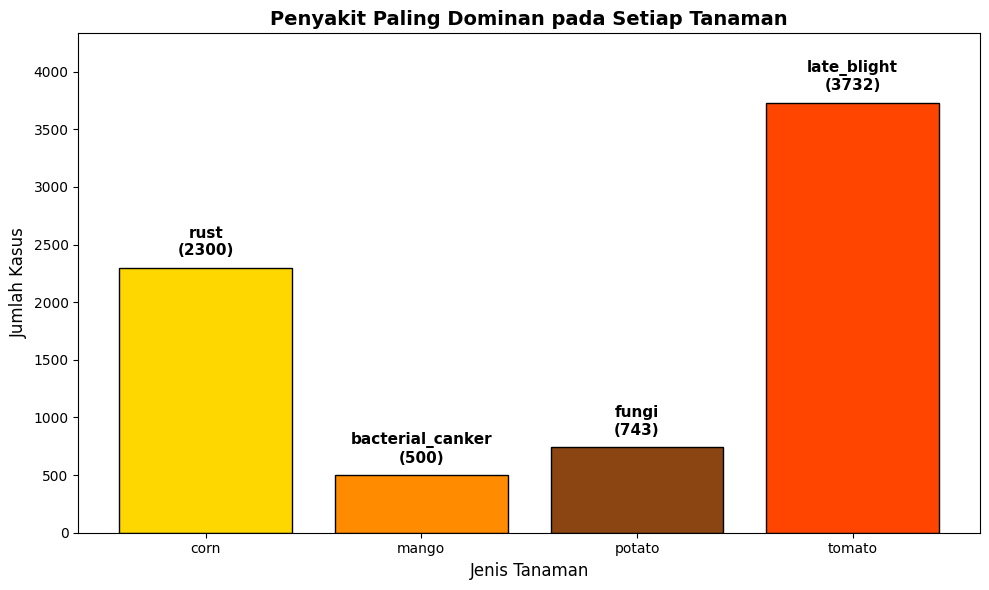

In [58]:
# 1. Menghitung jumlah masing-masing penyakit per tanaman
disease_counts = df_disease.groupby(['plant', 'disease']).size().reset_index(name='count')

# 2. Mengambil penyakit dengan jumlah kasus tertinggi (dominan) untuk setiap tanaman
# Kita mencari index dari nilai maksimum ('count') per kelompok ('plant')
idx_max = disease_counts.groupby('plant')['count'].idxmax()
dominant_diseases = disease_counts.loc[idx_max].reset_index(drop=True)

print("--- Penyakit Paling Dominan per Tanaman ---")
display(dominant_diseases)

# 3. Visualisasi Bar Chart
plt.figure(figsize=(10, 6))

# Membuat bar chart
bars = plt.bar(
    dominant_diseases['plant'],
    dominant_diseases['count'],
    color=['#FFD700', '#FF8C00', '#8B4513', '#FF4500'],
    edgecolor='black'
)

# Menambahkan teks nama penyakit dan jumlahnya tepat di atas bar
for bar, disease, count in zip(bars, dominant_diseases['disease'], dominant_diseases['count']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f"{disease}\n({count})",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Penyakit Paling Dominan pada Setiap Tanaman", fontsize=14, fontweight='bold')
plt.xlabel("Jenis Tanaman", fontsize=12)
plt.ylabel("Jumlah Kasus", fontsize=12)

# Memperluas sumbu Y sedikit ke atas agar teks tidak terpotong
plt.ylim(0, dominant_diseases['count'].max() + 600)

plt.tight_layout()
plt.show()

**Insight :**

**Tomat**: Penyakit yang paling dominan adalah late_blight dengan 3.732 kasus. Mengingat tomat mendominasi porsi dataset, penyakit ini menjadi yang paling banyak ditemui secara keseluruhan.

**Jagung**: Penyakit yang paling sering menyerang adalah rust (karat daun) dengan 2.300 kasus.

**Kentang**: Penyakit paling dominan adalah fungi (jamur) dengan 743 kasus.

**Mangga**: Kasus penyakit pada mangga tersebar sangat merata (seimbang) di angka 500 kasus untuk beberapa penyakit sekaligus. Algoritma menangkap bacterial_canker sebagai salah satu perwakilan dominan, namun pada kenyataannya, penyakit seperti cutting weevil, gall midge, dan powdery mildew juga memiliki jumlah kasus yang sama persis (500 kasus).

Pertanyaan 3: Bagaimana distribusi jumlah kasus penyakit tanaman pada setiap wilayah (Sumatera, Jawa, Kalimantan, dan Sulawesi) selama periode pengamatan?

--- Distribusi Kasus Penyakit per Wilayah ---


,Wilayah,Jumlah Kasus
0,Sulawesi,9897
1,Sumatera,9890
2,Jawa,9888
3,Kalimantan,9812


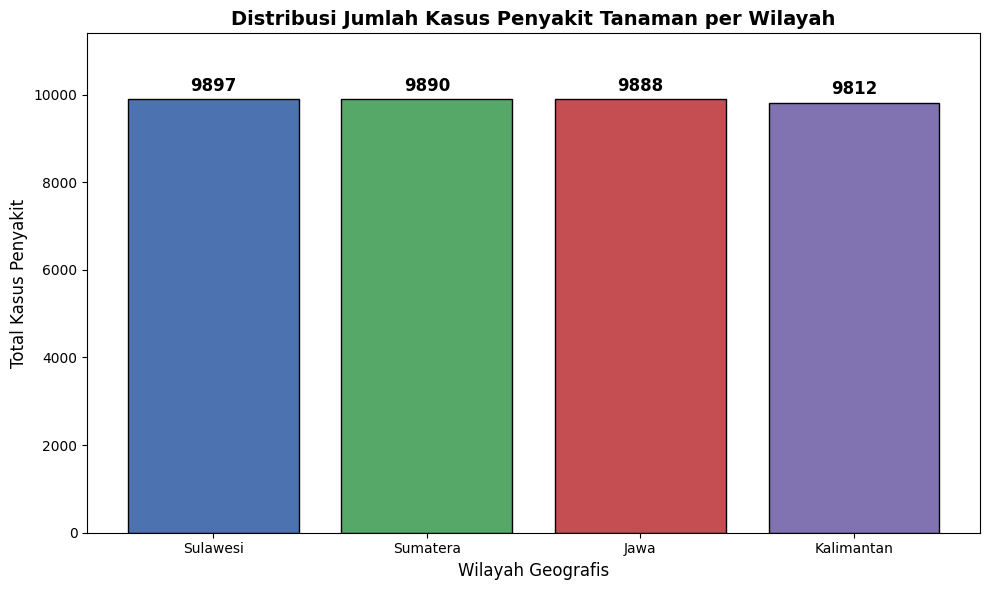

In [59]:
# 1. Menghitung jumlah kasus penyakit per wilayah (menggunakan df_disease yang sudah membuang kelas 'healthy')
region_counts = df_disease['location'].value_counts().reset_index()
region_counts.columns = ['Wilayah', 'Jumlah Kasus']

print("--- Distribusi Kasus Penyakit per Wilayah ---")
display(region_counts)

# 2. Visualisasi Bar Chart
plt.figure(figsize=(10, 6))

bars = plt.bar(
    region_counts['Wilayah'],
    region_counts['Jumlah Kasus'],
    color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'],
    edgecolor='black'
)

# Menambahkan teks angka persis di atas setiap bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f"{int(bar.get_height())}",
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

plt.title("Distribusi Jumlah Kasus Penyakit Tanaman per Wilayah", fontsize=14, fontweight='bold')
plt.xlabel("Wilayah Geografis", fontsize=12)
plt.ylabel("Total Kasus Penyakit", fontsize=12)

# Memperluas sumbu Y ke atas agar teks angka tidak keluar batas
plt.ylim(0, region_counts['Jumlah Kasus'].max() + 1500)

plt.tight_layout()
plt.show()

**Insight :**

**Distribusi Sangat Merata:** Berdasarkan visualisasi, jumlah kasus penyakit tanaman tersebar secara sangat merata dan seimbang di keempat wilayah (Sulawesi, Sumatera, Jawa, dan Kalimantan), di mana masing-masing wilayah mencatatkan sekitar ~9.800 kasus (angka bervariasi sangat tipis).

**Karakteristik Data Sintetis:** Kemerataan ini mencerminkan karakteristik dari synthetic metadata engineering yang kita lakukan sebelumnya, di mana lokasi di-generate menggunakan metode random.choice() tanpa pembobotan khusus (unweighted random assignment).

**Dampak untuk Web-GIS:** Untuk kebutuhan pengembangan Geospatial Dashboard (Web-GIS) proyek VANGROVE, distribusi yang seimbang ini sangat ideal karena memungkinkan pengujian peta interaktif yang merata di seluruh titik koordinat Indonesia (tidak ada wilayah peta yang kosong).

Pertanyaan 4: Kondisi lingkungan apa yang paling sering terkait dengan kemunculan masing-masing jenis penyakit tanaman?

--- 10 Kondisi Lingkungan Pemicu Penyakit Teratas ---


,Kondisi Lingkungan,Total Kemunculan
0,kelembaban tinggi,19381
1,lembap,4039
2,hujan,3732
3,percikan air,3623
4,air mengenai daun,3553
5,ventilasi buruk,3094
6,kelembaban >85%,3094
7,tanah terinfeksi,2814
8,virus,2736
9,alat terkontaminasi,2736


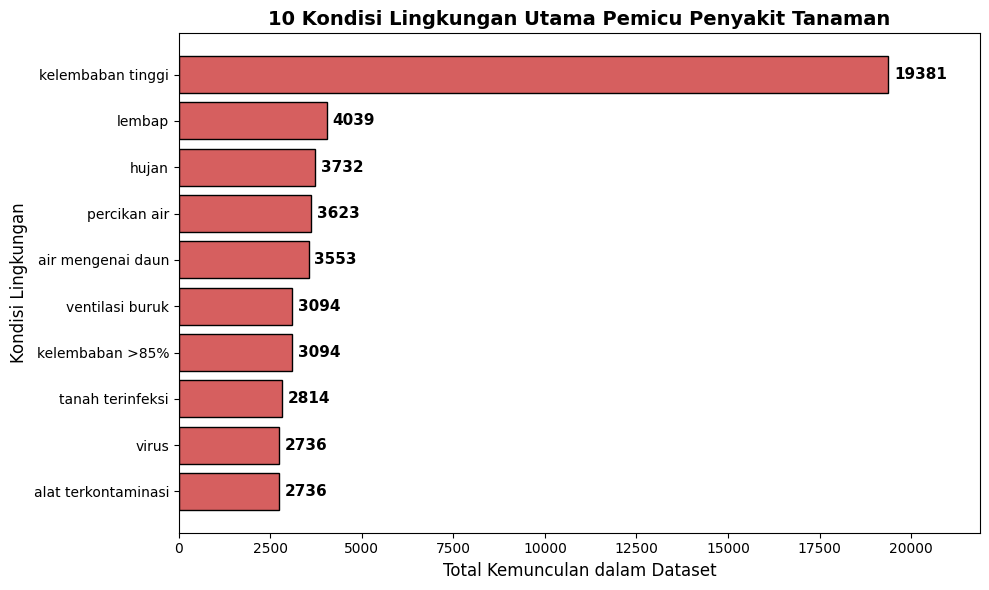

In [60]:
# 1. Menggunakan df_exploded yang sudah ada, tapi buang kelas 'healthy' (hanya fokus pada penyakit)
df_disease_cond = df_exploded[df_exploded['disease'] != 'healthy']

# 2. Menghitung 10 kondisi lingkungan pemicu penyakit yang paling sering muncul
top_conditions = df_disease_cond['condition'].value_counts().head(10).reset_index()
top_conditions.columns = ['Kondisi Lingkungan', 'Total Kemunculan']

print("--- 10 Kondisi Lingkungan Pemicu Penyakit Teratas ---")
display(top_conditions)

# 3. Visualisasi Horizontal Bar Chart
plt.figure(figsize=(10, 6))

# Kita balik urutannya ([::-1]) agar bar tertinggi muncul di posisi paling atas
bars = plt.barh(
    top_conditions['Kondisi Lingkungan'][::-1],
    top_conditions['Total Kemunculan'][::-1],
    color='#D65F5F',
    edgecolor='black'
)

# Menambahkan teks angka persis di sebelah kanan setiap bar
for bar in bars:
    plt.text(
        bar.get_width() + 150,
        bar.get_y() + bar.get_height() / 2,
        f"{int(bar.get_width())}",
        va='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title("10 Kondisi Lingkungan Utama Pemicu Penyakit Tanaman", fontsize=14, fontweight='bold')
plt.xlabel("Total Kemunculan dalam Dataset", fontsize=12)
plt.ylabel("Kondisi Lingkungan", fontsize=12)

# Memperluas sumbu X ke kanan agar teks angka tidak keluar batas
plt.xlim(0, top_conditions['Total Kemunculan'].max() + 2500)

plt.tight_layout()
plt.show()

**Insight :**

**Dominasi Faktor Air & Kelembaban:** Dari visualisasi di atas, terlihat sangat jelas bahwa "Kelembaban Tinggi" adalah musuh utama bagi tanaman. Kondisi ini mendominasi dengan lebih dari 19.000 kemunculan, yang memicu berbagai penyakit lintas tanaman (seperti Blight, Rust, hingga Fungi).

**Lima pemicu teratas secara konsisten berkaitan dengan kadar air, yaitu:** Kelembaban tinggi, lembap, hujan, percikan air, dan air mengenai daun. Hal ini memberikan wawasan bahwa pengendalian sistem irigasi, perbaikan drainase, dan jarak tanam (untuk sirkulasi udara) adalah rekomendasi agrikultur yang paling krusial.

**Faktor Transmisi (Penularan):** Selain faktor lingkungan, alat kebun yang terkontaminasi dan keberadaan vektor serangga (virus) juga masuk ke dalam daftar pemicu utama. Ini menegaskan pentingnya Standard Operating Procedure (SOP) sterilisasi alat dan pengelolaan hama terpadu di lapangan.

Pertanyaan 5: Apakah terdapat tren peningkatan atau penurunan jumlah kasus penyakit tanaman dari bulan ke bulan selama periode Januari 2023 hingga November 2024?

--- Tren Jumlah Kasus per Bulan ---


/tmp/ipykernel_5683/705367348.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_disease['year_month'] = df_disease['date'].dt.to_period('M')


,year_month,Jumlah Kasus
0,2023-01,1765
1,2023-02,1530
2,2023-03,1694
3,2023-04,1702
4,2023-05,1741


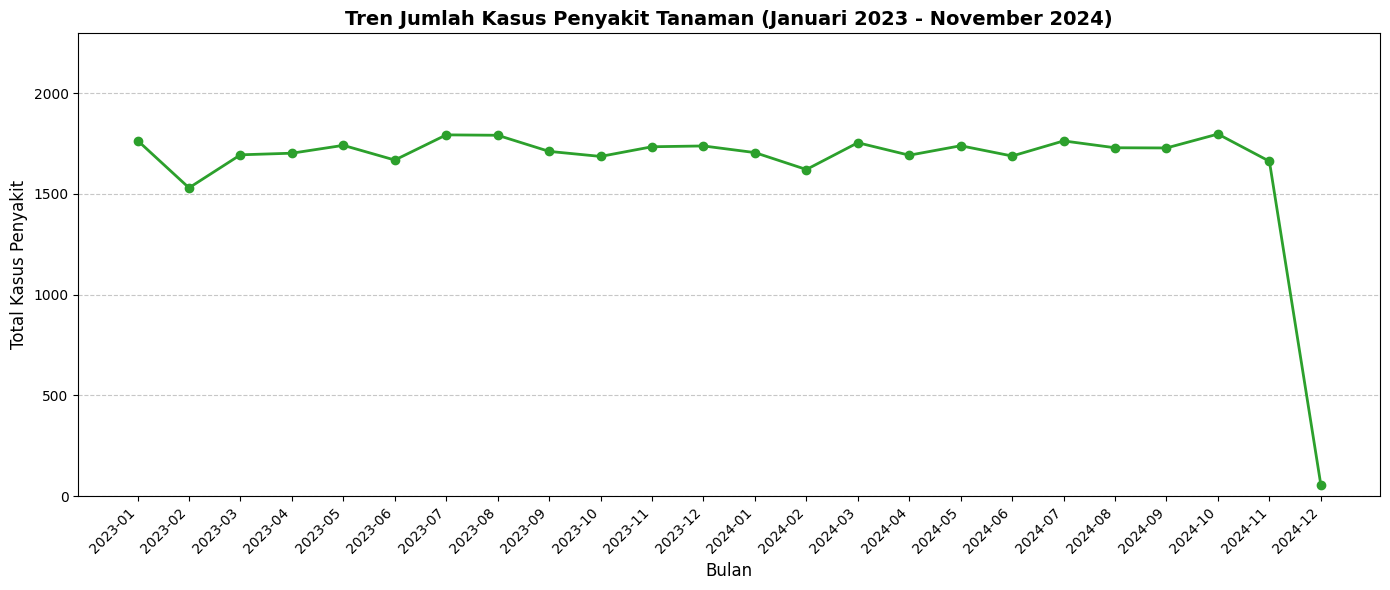

In [61]:
# 1. Menghitung jumlah kasus penyakit per bulan
# Kita gunakan df_disease agar kelas 'healthy' tidak ikut terhitung
df_disease['year_month'] = df_disease['date'].dt.to_period('M')
monthly_trend = df_disease.groupby('year_month').size().reset_index(name='Jumlah Kasus')

# Mengubah tipe data year_month menjadi string agar mudah dibaca pada sumbu X grafik
monthly_trend['year_month'] = monthly_trend['year_month'].astype(str)

print("--- Tren Jumlah Kasus per Bulan ---")
display(monthly_trend.head())

# 2. Visualisasi Line Chart
plt.figure(figsize=(14, 6))

# Membuat garis tren
plt.plot(
    monthly_trend['year_month'],
    monthly_trend['Jumlah Kasus'],
    marker='o',          # Menambahkan titik pada setiap bulan
    linestyle='-',       # Gaya garis solid
    color='#2CA02C',     # Warna hijau agar sesuai tema agrikultur
    linewidth=2,
    markersize=6
)

# Menambahkan judul dan label
plt.title("Tren Jumlah Kasus Penyakit Tanaman (Januari 2023 - November 2024)", fontsize=14, fontweight='bold')
plt.xlabel("Bulan", fontsize=12)
plt.ylabel("Total Kasus Penyakit", fontsize=12)

# Memutar label teks di sumbu X agar tidak tumpang tindih
plt.xticks(rotation=45, ha='right')

# Menambahkan grid (garis bantu) secara horizontal agar nilai mudah dibaca
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mengatur rentang sumbu Y (dimulai dari 0 agar fluktuasinya tidak terlihat berlebihan)
plt.ylim(0, monthly_trend['Jumlah Kasus'].max() + 500)

plt.tight_layout()
plt.show()

**Insight :**

**idak Ada Tren Signifikan (Stagnan/Fluktuatif Ringan):** Berdasarkan grafik time series di atas, jumlah kasus penyakit tanaman berfluktuasi secara acak di kisaran angka 1.500 hingga 1.800 kasus per bulannya tanpa menunjukkan tren kenaikan maupun penurunan yang konsisten.

**Ketiadaan Pola Musiman (Seasonality):** Grafik ini tidak memperlihatkan adanya lonjakan kasus di bulan-bulan tertentu (misalnya saat musim hujan di akhir/awal tahun). Hal ini sepenuhnya wajar karena tanggal pada dataset ini di-generate secara sintetis menggunakan distribusi acak seragam (uniform random distribution) tanpa menyertakan bobot musim.

**Kesiapan Infrastruktur Dashboard:** Terlepas dari sifat datanya yang sintetis, visualisasi ini membuktikan bahwa pipeline data yang dibangun sudah siap. Ketika dataset riil (yang memiliki timestamp asli) masuk ke dalam sistem VANGROVE, pipeline ini sudah 100% mampu membaca dan memetakan pola wabah penyakit dari waktu ke waktu.